# ICU Infection Prevention Adherence: Inferential Statistics

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_rater = pd.read_csv('data/icu_adherence_by_rater.csv')
df_items = pd.read_csv('data/icu_adherence_by_item.csv').iloc[:, 1:]

df_rater_avg = df_rater.groupby(['icu_id', 'icu_type'])[['clabsi_score', 'cauti_score', 'vap_score']].mean()
df_rater_avg.reset_index(inplace=True)
df_rater_avg.head(10)

,icu_id,icu_type,clabsi_score,cauti_score,vap_score
0,1,General,77.845,74.760,64.780
1,2,General,61.175,78.335,80.435
2,3,General,73.135,77.740,76.955
3,4,General,79.310,90.715,77.395
4,5,General,70.785,73.215,87.395
5,6,General,69.510,65.240,68.265
6,7,General,69.510,70.240,68.045
7,8,General,70.100,86.670,67.610
8,9,General,64.415,70.950,67.825
9,10,Surgical,88.925,87.020,66.525


### Correlation Between Prevention Category Adherence Rates

In [3]:
score_cols = ['clabsi_score', 'cauti_score', 'vap_score']
correlation_matrix = df_rater_avg[score_cols].corr(method="pearson")

correlation_matrix.round(3)

,clabsi_score,cauti_score,vap_score
clabsi_score,1.000,0.661,0.082
cauti_score,0.661,1.000,0.322
vap_score,0.082,0.322,1.000


In [4]:
from scipy.stats import pearsonr

clabsi_cauti_corr, clabsi_cauti_p = pearsonr(df_rater_avg['clabsi_score'], df_rater_avg['cauti_score'])
clabsi_vap_corr, clabsi_vap_p = pearsonr(df_rater_avg['clabsi_score'], df_rater_avg['vap_score'])
cauti_vap_corr, cauti_vap_p = pearsonr(df_rater_avg['cauti_score'], df_rater_avg['vap_score'])

print(
f"""
Correlations (Pearson's r and p-values):
    CLABSI vs CAUTI:
        r = {clabsi_cauti_corr:.3f}   p-value = {clabsi_cauti_p:.3f}
    CLABSI vs VAP:
        r = {clabsi_vap_corr:.3f}   p-value = {clabsi_vap_p:.3f}
    CAUTI vs VAP:
        r = {cauti_vap_corr:.3f}   p-value = {cauti_vap_p:.3f}
"""
)


Correlations (Pearson's r and p-values):
    CLABSI vs CAUTI:
        r = 0.661   p-value = 0.002
    CLABSI vs VAP:
        r = 0.082   p-value = 0.732
    CAUTI vs VAP:
        r = 0.322   p-value = 0.166



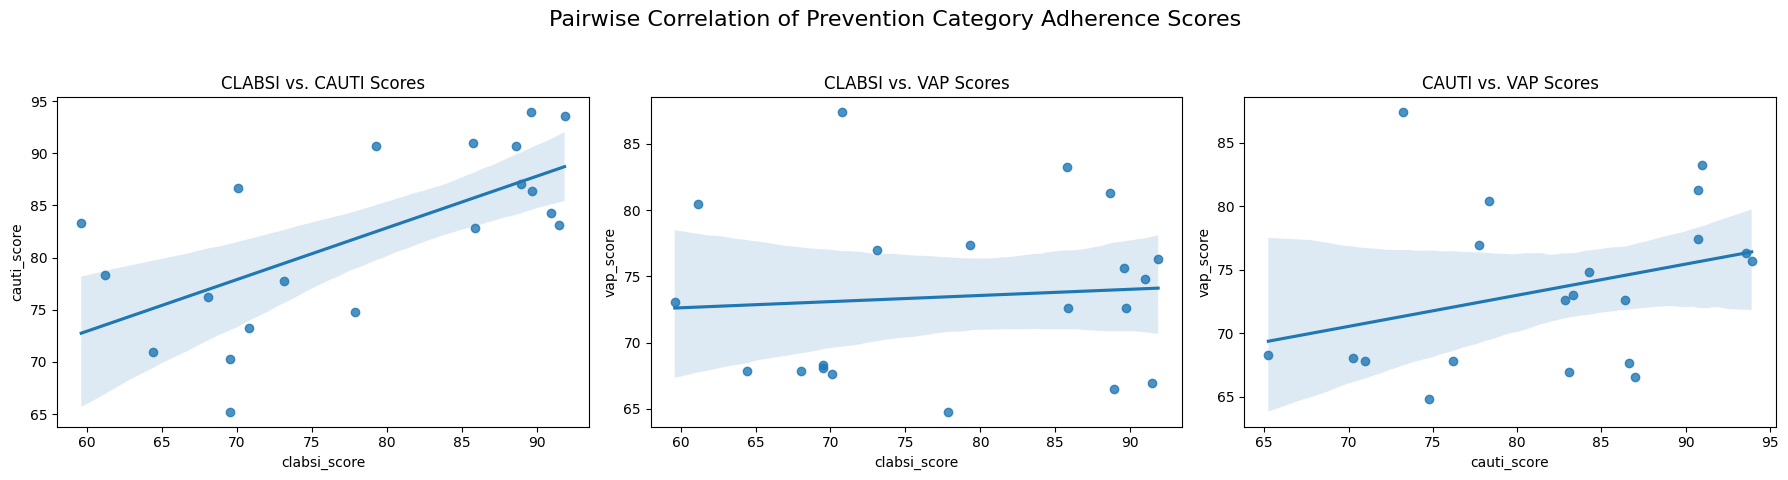

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Pairwise Correlation of Prevention Category Adherence Scores', fontsize=16)

# CLABSI vs. CAUTI
sns.regplot(ax=axes[0], data=df_rater_avg, x='clabsi_score', y='cauti_score')
axes[0].set_title('CLABSI vs. CAUTI Scores')

# CLABSI vs. VAP
sns.regplot(ax=axes[1], data=df_rater_avg, x='clabsi_score', y='vap_score')
axes[1].set_title('CLABSI vs. VAP Scores')

# CAUTI vs. VAP
sns.regplot(ax=axes[2], data=df_rater_avg, x='cauti_score', y='vap_score')
axes[2].set_title('CAUTI vs. VAP Scores')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

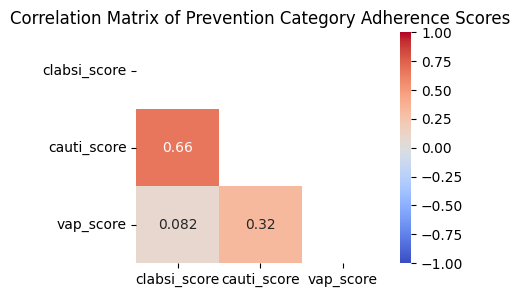

In [6]:
# sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
# plt.title('Correlation Matrix of Prevention Category Adherence Scores')
# plt.show()

# To make the heatmap less redundant, we'll create a 'mask' for the upper triangle
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

plt.figure(figsize=(4, 3))
sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix of Prevention Category Adherence Scores')
plt.show()

**Interpretation of Correlation Analyses**:
As indicated in the table, correlation graphs, and the heatmap, a strong, statistically significant positive correlation (r=0.661, p-value=0.002) exists between adherence to CLABSI and CAUTI prevention categories. This suggests that ICUs with high adherence to one tend to have high adherence to the other. However, VAP prevention adherence does not show a significant correlation with the other two, indicating that adherence to ventilator protocols is likely influenced by a different set of factors.

### Testing for Homogeneity of Variances (Levene's Test)

Before we can perform an ANOVA to compare the means of our ICU groups, we must first test the assumption that the groups have equal variances. We will use Levene's test for this.

In [7]:
from scipy.stats import levene

icu_types = df_rater_avg['icu_type'].unique()

# Prepare lists of samples for each category
clabsi_samples = [df_rater_avg['clabsi_score'][df_rater_avg['icu_type'] == t] for t in icu_types]
cauti_samples = [df_rater_avg['cauti_score'][df_rater_avg['icu_type'] == t] for t in icu_types]
vap_samples = [df_rater_avg['vap_score'][df_rater_avg['icu_type'] == t] for t in icu_types]

# Perform Levene's test for each category
levene_clabsi_stat, levene_clabsi_p = levene(*clabsi_samples, center='mean')
levene_cauti_stat, levene_cauti_p = levene(*cauti_samples, center='mean')
levene_vap_stat, levene_vap_p = levene(*vap_samples, center='mean')

print("Levene's Test for Homogeneity of Variances")
print(f"CLABSI: Levene's Test Statistic = {levene_clabsi_stat:.3f}, p-value = {levene_clabsi_p:.3f}")
print(f"CAUTI: Levene's Test Statistic = {levene_cauti_stat:.3f}, p-value = {levene_cauti_p:.3f}")
print(f"VAP: Levene's Test Statistic = {levene_vap_stat:.3f}, p-value = {levene_vap_p:.3f}")

Levene's Test for Homogeneity of Variances
CLABSI: Levene's Test Statistic = 0.740, p-value = 0.492
CAUTI: Levene's Test Statistic = 1.278, p-value = 0.304
VAP: Levene's Test Statistic = 4.225, p-value = 0.032


**Interpretation of Levene's Test**:
The test results show that the p-values for the CLABSI and CAUTI categories are greater than 0.05. Therefore, we do not reject the null hypothesis of equal variances for these groups. We can proceed with a standard ANOVA test.
However, the p-value for the VAP category is less than 0.05, indicating that the variances among the ICU groups for VAP adherence are significantly different. This violates the assumption of homogeneity of variance, so we must use a more robust test (like Welch's ANOVA) for this category instead of the standard ANOVA.

### ANOVA for CLABSI and CAUTI

In [8]:
from scipy.stats import f_oneway

# ANOVA for CLABSI scores
f_stat_clabsi, p_val_clabsi = f_oneway(*clabsi_samples)
print(f"CLABSI ANOVA: F-statistic = {f_stat_clabsi:.3f}, p-value = {p_val_clabsi:.3f}")

# ANOVA for CAUTI scores
f_stat_cauti, p_val_cauti = f_oneway(*cauti_samples)
print(f"CAUTI ANOVA: F-statistic = {f_stat_cauti:.3f}, p-value = {p_val_cauti:.3f}")

CLABSI ANOVA: F-statistic = 6.508, p-value = 0.008
CAUTI ANOVA: F-statistic = 5.381, p-value = 0.015


**Interpretation of ANOVA**:\
The ANOVA results show a statistically significant difference among the ICU types for both CLABSI prevention adherence (p < 0.01) and CAUTI prevention adherence (p < 0.05). This tells us that at least one ICU type has a different mean adherence score from the others for these two prevention categories. To find out exactly which groups differ, we will need to perform post-hoc tests later.

### Welch's ANOVA for VAP

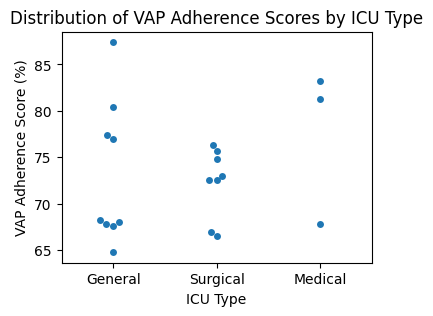

In [9]:
plt.figure(figsize=(4, 3))
sns.swarmplot(data=df_rater_avg, x='icu_type', y='vap_score')
plt.title('Distribution of VAP Adherence Scores by ICU Type')
plt.xlabel('ICU Type')
plt.ylabel('VAP Adherence Score (%)')
plt.show()

In [10]:
import statsmodels.stats.oneway as oneway

# Prepare the data in the required format for the function: a tuple of arrays, one for each group.
vap_samples_by_icu_type = (
    df_rater_avg['vap_score'][df_rater_avg['icu_type'] == 'General'],
    df_rater_avg['vap_score'][df_rater_avg['icu_type'] == 'Surgical'],
    df_rater_avg['vap_score'][df_rater_avg['icu_type'] == 'Medical']
)

welch_stat, welch_p_value = oneway.anova_oneway(
    vap_samples_by_icu_type,
    use_var='unequal'
)

print("Welch's ANOVA for VAP Measures")
print(f"Statistic: {welch_stat:.4f}")
print(f"P-value:   {welch_p_value:.4f}")

Welch's ANOVA for VAP Measures
Statistic: 0.4791
P-value:   0.6452


**Interpretation of Welch's ANOVA**:
The result of the Welch's ANOVA test shows a p-value that is not significant (p > 0.05). Therefore, we conclude that there is no statistically significant difference in the mean adherence to ventilator (VAP) prevention category among the different types of ICUs.

### Post-Hoc Analysis (Tukey's HSD Test)

Since the main ANOVA tests for CLABSI and CAUTI were significant, we will now perform Tukey's Honestly Significant Difference (HSD) test to find out which specific group pairs are different from each other.

In [11]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Tukey's test for CLABSI scores
tukey_clabsi = pairwise_tukeyhsd(endog=df_rater_avg['clabsi_score'], groups=df_rater_avg['icu_type'], alpha=0.05)
print('Tukey HSD for CLABSI Adherence')
print(tukey_clabsi)

# Tukey's test for CAUTI scores
tukey_cauti = pairwise_tukeyhsd(endog=df_rater_avg['cauti_score'], groups=df_rater_avg['icu_type'], alpha=0.05)
print('\n Tukey HSD for CAUTI Adherence')
print(tukey_cauti)

Tukey HSD for CLABSI Adherence
  Multiple Comparison of Means - Tukey HSD, FWER=0.05   
 group1  group2  meandiff p-adj   lower    upper  reject
--------------------------------------------------------
General  Medical  10.1756 0.2256  -4.9761 25.3272  False
General Surgical  15.3622 0.0063   4.3187 26.4058   True
Medical Surgical   5.1867  0.669 -10.1999 20.5732  False
--------------------------------------------------------

 Tukey HSD for CAUTI Adherence
  Multiple Comparison of Means - Tukey HSD, FWER=0.05   
 group1  group2  meandiff p-adj   lower    upper  reject
--------------------------------------------------------
General  Medical   9.5206 0.1259  -2.2721 21.3132  False
General Surgical  10.3868  0.017   1.7915 18.9821   True
Medical Surgical   0.8663 0.9812 -11.1092 12.8417  False
--------------------------------------------------------


**Interpretation of Tukey's HSD Test**:

The post-hoc analysis reveals the source of the differences:

* For CLABSI Adherence: There is a statistically significant difference between Surgical and General ICUs. Surgical ICUs have a mean adherence score that is approximately 15.4 points higher than General ICUs. No other group differences are significant.

* For CAUTI Adherence: Similarly, the only significant difference is between Surgical and General ICUs, with Surgical ICUs scoring about 10.4 points higher.